## Analysis 1: Predict Price Based on Categorical X values

Regression 
Y =  Price
X =  Features (Area, Bedrooms, Bathroom, Location,... etc)

In [1]:
from sklearn.linear_model import LinearRegression

In [20]:
import pandas as pd

list_cities = ["Leicester", "Birmingham", "London", "Glasgow", "Edinburgh", "Newcastle", "Bristol", "Manchester", "Nottingham", "Sheffield", "Liverpool", "Cardiff", "Belfast", "Leeds", "Southampton"]

df_list = []

for city in list_cities:
    df_temp = pd.read_csv(f"CLEANED_DATA/rightmove/rm_properties_{city.lower()}.csv")
    df_temp["city"] = city
    df_list.append(df_temp)

df_all_cities_original = pd.concat(df_list, ignore_index=True)

df_all_cities = df_all_cities_original.copy()
df_all_cities = df_all_cities.dropna(subset=['price'])
df_all_cities

,title,location,price,property_type,bedrooms,bathrooms,area,link,city
0,"Stone Penn Lane, Holwell, Melton Mowbray","Stone Penn Lane, Holwell, Melton Mowbray",1750000.0,Equestrian Facility,4.0,2.0,NaN,https://www.rightmove.co.uk/properties/1736345...,Leicester
1,"Hallaton, Hallaton, LE16","Hallaton, Hallaton, LE16",1175000.0,Detached,5.0,2.0,NaN,https://www.rightmove.co.uk/properties/1736637...,Leicester
2,"Wibtoft, Warwickshire","Wibtoft, Warwickshire",950000.0,Detached,5.0,3.0,NaN,https://www.rightmove.co.uk/properties/1736322...,Leicester
3,"Bakehouse Lane, Twyford","Bakehouse Lane, Twyford",850000.0,Detached,4.0,3.0,NaN,https://www.rightmove.co.uk/properties/1736713...,Leicester
4,"Main Street, Fleckney, Leicester","Main Street, Fleckney, Leicester",650000.0,Detached,5.0,2.0,NaN,https://www.rightmove.co.uk/properties/1736208...,Leicester
...,...,...,...,...,...,...,...,...,...
328,"St. Marys Road, Netley Abbey, Hampshire, SO31","St. Marys Road, Netley Abbey, Hampshire, SO31",1100000.0,Semi-Detached,4.0,3.0,NaN,https://www.rightmove.co.uk/properties/1727186...,Southampton
329,"Highfield, Southampton","Highfield, Southampton",995000.0,Detached,4.0,2.0,NaN,https://www.rightmove.co.uk/properties/8719473...,Southampton
330,"Beechmount Road, Bassett, Southampton, Hampshi...","Beechmount Road, Bassett, Southampton, Hampshi...",995000.0,Detached,5.0,4.0,NaN,https://www.rightmove.co.uk/properties/1720234...,Southampton
331,"Pinehurst Road, Southampton","Pinehurst Road, Southampton",995000.0,Detached,5.0,3.0,NaN,https://www.rightmove.co.uk/properties/1730982...,Southampton


In [21]:
df_all_cities["area"]  = df_all_cities["area"].fillna(df_all_cities["area"].median(), inplace=True)
df_all_cities["bedrooms"]  = df_all_cities["bedrooms"].fillna(df_all_cities["bedrooms"].mean(), inplace=True)
df_all_cities["bathrooms"]  = df_all_cities["bathrooms"].fillna(df_all_cities["bathrooms"].mean(), inplace=True)

/var/folders/zb/ckbmp2j1113556mqnd3w6n0w0000gn/T/ipykernel_11488/10189826.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_all_cities["area"]  = df_all_cities["area"].fillna(df_all_cities["area"].median(), inplace=True)
/var/folders/zb/ckbmp2j1113556mqnd3w6n0w0000gn/T/ipykernel_11488/10189826.py:2: ChainedAssignmentError: A val

In [22]:
df_all_cities

,title,location,price,property_type,bedrooms,bathrooms,area,link,city
0,"Stone Penn Lane, Holwell, Melton Mowbray","Stone Penn Lane, Holwell, Melton Mowbray",1750000.0,Equestrian Facility,4.0,2.0,393.5,https://www.rightmove.co.uk/properties/1736345...,Leicester
1,"Hallaton, Hallaton, LE16","Hallaton, Hallaton, LE16",1175000.0,Detached,5.0,2.0,393.5,https://www.rightmove.co.uk/properties/1736637...,Leicester
2,"Wibtoft, Warwickshire","Wibtoft, Warwickshire",950000.0,Detached,5.0,3.0,393.5,https://www.rightmove.co.uk/properties/1736322...,Leicester
3,"Bakehouse Lane, Twyford","Bakehouse Lane, Twyford",850000.0,Detached,4.0,3.0,393.5,https://www.rightmove.co.uk/properties/1736713...,Leicester
4,"Main Street, Fleckney, Leicester","Main Street, Fleckney, Leicester",650000.0,Detached,5.0,2.0,393.5,https://www.rightmove.co.uk/properties/1736208...,Leicester
...,...,...,...,...,...,...,...,...,...
328,"St. Marys Road, Netley Abbey, Hampshire, SO31","St. Marys Road, Netley Abbey, Hampshire, SO31",1100000.0,Semi-Detached,4.0,3.0,393.5,https://www.rightmove.co.uk/properties/1727186...,Southampton
329,"Highfield, Southampton","Highfield, Southampton",995000.0,Detached,4.0,2.0,393.5,https://www.rightmove.co.uk/properties/8719473...,Southampton
330,"Beechmount Road, Bassett, Southampton, Hampshi...","Beechmount Road, Bassett, Southampton, Hampshi...",995000.0,Detached,5.0,4.0,393.5,https://www.rightmove.co.uk/properties/1720234...,Southampton
331,"Pinehurst Road, Southampton","Pinehurst Road, Southampton",995000.0,Detached,5.0,3.0,393.5,https://www.rightmove.co.uk/properties/1730982...,Southampton


In [23]:
X = df_all_cities[["area", "bedrooms", "bathrooms", "property_type"]]
X
X = pd.get_dummies(X, columns=["property_type"], drop_first=True)
X

,area,bedrooms,bathrooms,property_type_Block of Apartments,property_type_Character Property,property_type_Country House,property_type_Detached,property_type_Detached Villa,property_type_End of Terrace,property_type_Equestrian Facility,...,property_type_House,property_type_Land,property_type_Link Detached House,property_type_Not Specified,property_type_Penthouse,property_type_Plot,property_type_Semi-Detached,property_type_Serviced Apartments,property_type_Terraced,property_type_Town House
0,393.5,4.0,2.0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,393.5,5.0,2.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,393.5,5.0,3.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,393.5,4.0,3.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,393.5,5.0,2.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,393.5,4.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
329,393.5,4.0,2.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
330,393.5,5.0,4.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
331,393.5,5.0,3.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
len(X.columns)

22

In [24]:
y = df_all_cities["price"]
y

0      1750000.0
1      1175000.0
2       950000.0
3       850000.0
4       650000.0
         ...    
328    1100000.0
329     995000.0
330     995000.0
331     995000.0
332     995000.0
Name: price, Length: 330, dtype: float64

In [25]:
y.isnull().sum()

np.int64(0)

In [26]:
X.isnull().sum()

area                                 0
bedrooms                             0
bathrooms                            0
property_type_Block of Apartments    0
property_type_Character Property     0
property_type_Country House          0
property_type_Detached               0
property_type_Detached Villa         0
property_type_End of Terrace         0
property_type_Equestrian Facility    0
property_type_Farm House             0
property_type_Flat                   0
property_type_House                  0
property_type_Land                   0
property_type_Link Detached House    0
property_type_Not Specified          0
property_type_Penthouse              0
property_type_Plot                   0
property_type_Semi-Detached          0
property_type_Serviced Apartments    0
property_type_Terraced               0
property_type_Town House             0
dtype: int64

In [27]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'property_type_Block of Apartments',
       'property_type_Character Property', 'property_type_Country House',
       'property_type_Detached', 'property_type_Detached Villa',
       'property_type_End of Terrace', 'property_type_Equestrian Facility',
       'property_type_Farm House', 'property_type_Flat', 'property_type_House',
       'property_type_Land', 'property_type_Link Detached House',
       'property_type_Not Specified', 'property_type_Penthouse',
       'property_type_Plot', 'property_type_Semi-Detached',
       'property_type_Serviced Apartments', 'property_type_Terraced',
       'property_type_Town House'],
      dtype='str')

In [31]:
model.coef_

array([    7143.38650404,   168689.59645355,   752412.74103622,
       -2851038.16823185, -2951038.16823185, -4069877.07163135,
       -3065179.33223195, -3089325.49240539, -3399594.7477502 ,
       -1100259.65561558,  -626016.6752436 ,  7076975.27865178,
         428169.51939431, -3365380.524164  , -3499806.0034342 ,
       -2753538.16823185,  2152745.41026321, -3094075.35040866,
        -368426.92144742,  -322444.85939825,  -113651.70805619,
        -983460.15925866])

In [34]:
model.intercept_

np.float64(-1765246.801610251)

In [36]:
list(X.columns)

['area',
 'bedrooms',
 'bathrooms',
 'property_type_Block of Apartments',
 'property_type_Character Property',
 'property_type_Country House',
 'property_type_Detached',
 'property_type_Detached Villa',
 'property_type_End of Terrace',
 'property_type_Equestrian Facility',
 'property_type_Farm House',
 'property_type_Flat',
 'property_type_House',
 'property_type_Land',
 'property_type_Link Detached House',
 'property_type_Not Specified',
 'property_type_Penthouse',
 'property_type_Plot',
 'property_type_Semi-Detached',
 'property_type_Serviced Apartments',
 'property_type_Terraced',
 'property_type_Town House']

In [37]:
table_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

table_df

,Feature,Coefficient
0,area,7.143387e+03
1,bedrooms,1.686896e+05
2,bathrooms,7.524127e+05
3,property_type_Block of Apartments,-2.851038e+06
4,property_type_Character Property,-2.951038e+06
5,property_type_Country House,-4.069877e+06
6,property_type_Detached,-3.065179e+06
7,property_type_Detached Villa,-3.089325e+06
8,property_type_End of Terrace,-3.399595e+06
9,property_type_Equestrian Facility,-1.100260e+06


In [ ]:
y_pred = model.predict(X)
y_pred

array([ 2.12500000e+06,  3.28769920e+05,  1.08118266e+06,  9.12493064e+05,
        3.28769920e+05,  3.99062761e+06, -4.43235944e+05,  4.97459516e+05,
       -4.91182384e+05, -8.19778163e+05, -7.26914138e+05, -8.62638482e+05,
        1.08118266e+06, -7.61022014e+05,  1.60080323e+05,  1.60080323e+05,
       -1.60790784e+06,  1.08118266e+06,  1.08118266e+06,  1.60080323e+05,
        1.83359540e+06,  1.66490581e+06,  2.13261201e+05,  1.08118266e+06,
        1.60080323e+05,  3.60924548e+06, -1.00550621e+06,  3.02552233e+06,
        1.93573040e+06,  4.89633110e+04,  1.60080323e+05,  2.00228500e+06,
        2.68814314e+06, -3.84031586e+05, -3.65353106e+05, -1.20073481e+06,
        3.28769920e+05,  1.60080323e+05,  1.24987226e+06,  1.08118266e+06,
        7.93031411e+06,  1.05537922e+07,  7.00045933e+06,  1.44787179e+07,
        3.84448967e+06,  7.37974044e+06,  7.00045933e+06,  1.21673275e+07,
        1.21673275e+07,  1.33746392e+07,  5.11967720e+06,  5.11967720e+06,
        7.09965590e+06,  

In [45]:
X.shape

(330, 22)

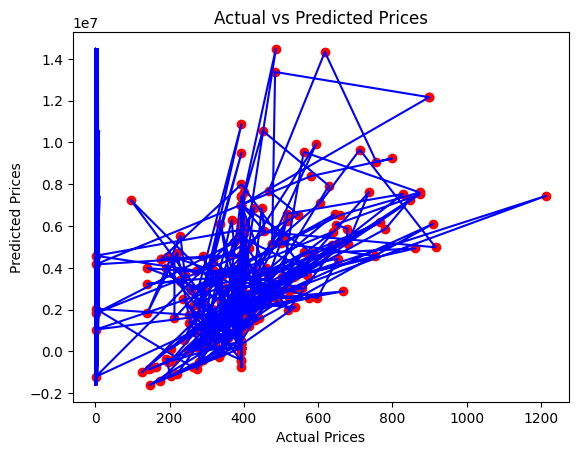

In [57]:
import matplotlib.pyplot as plt
plt.scatter(X["area"], y_pred, c='red')
plt.plot(X, y_pred, color='blue')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

Table Analysis
1. Each additional unit of area increases the price by 7143 Pounds
2. Each extra bedroom adds 168689

## Analysis 2: Predict Price Per Area

In [58]:
df_all_cities["price_per_sqm"] = df_all_cities["price"] / df_all_cities["area"]

In [59]:
df_all_cities

,title,location,price,property_type,bedrooms,bathrooms,area,link,city,price_per_sqm
0,"Stone Penn Lane, Holwell, Melton Mowbray","Stone Penn Lane, Holwell, Melton Mowbray",1750000.0,Equestrian Facility,4.0,2.0,393.5,https://www.rightmove.co.uk/properties/1736345...,Leicester,4447.268107
1,"Hallaton, Hallaton, LE16","Hallaton, Hallaton, LE16",1175000.0,Detached,5.0,2.0,393.5,https://www.rightmove.co.uk/properties/1736637...,Leicester,2986.022872
2,"Wibtoft, Warwickshire","Wibtoft, Warwickshire",950000.0,Detached,5.0,3.0,393.5,https://www.rightmove.co.uk/properties/1736322...,Leicester,2414.231258
3,"Bakehouse Lane, Twyford","Bakehouse Lane, Twyford",850000.0,Detached,4.0,3.0,393.5,https://www.rightmove.co.uk/properties/1736713...,Leicester,2160.101652
4,"Main Street, Fleckney, Leicester","Main Street, Fleckney, Leicester",650000.0,Detached,5.0,2.0,393.5,https://www.rightmove.co.uk/properties/1736208...,Leicester,1651.842440
...,...,...,...,...,...,...,...,...,...,...
328,"St. Marys Road, Netley Abbey, Hampshire, SO31","St. Marys Road, Netley Abbey, Hampshire, SO31",1100000.0,Semi-Detached,4.0,3.0,393.5,https://www.rightmove.co.uk/properties/1727186...,Southampton,2795.425667
329,"Highfield, Southampton","Highfield, Southampton",995000.0,Detached,4.0,2.0,393.5,https://www.rightmove.co.uk/properties/8719473...,Southampton,2528.589581
330,"Beechmount Road, Bassett, Southampton, Hampshi...","Beechmount Road, Bassett, Southampton, Hampshi...",995000.0,Detached,5.0,4.0,393.5,https://www.rightmove.co.uk/properties/1720234...,Southampton,2528.589581
331,"Pinehurst Road, Southampton","Pinehurst Road, Southampton",995000.0,Detached,5.0,3.0,393.5,https://www.rightmove.co.uk/properties/1730982...,Southampton,2528.589581


In [61]:
X = df_all_cities[["bedrooms", "bathrooms", "property_type", "city"]]
X

,bedrooms,bathrooms,property_type,city
0,4.0,2.0,Equestrian Facility,Leicester
1,5.0,2.0,Detached,Leicester
2,5.0,3.0,Detached,Leicester
3,4.0,3.0,Detached,Leicester
4,5.0,2.0,Detached,Leicester
...,...,...,...,...
328,4.0,3.0,Semi-Detached,Southampton
329,4.0,2.0,Detached,Southampton
330,5.0,4.0,Detached,Southampton
331,5.0,3.0,Detached,Southampton


In [62]:
X = pd.get_dummies(X, columns=["property_type", "city"], drop_first=True)
X

,bedrooms,bathrooms,property_type_Block of Apartments,property_type_Character Property,property_type_Country House,property_type_Detached,property_type_Detached Villa,property_type_End of Terrace,property_type_Equestrian Facility,property_type_Farm House,...,city_Glasgow,city_Leeds,city_Leicester,city_Liverpool,city_London,city_Manchester,city_Newcastle,city_Nottingham,city_Sheffield,city_Southampton
0,4.0,2.0,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,5.0,2.0,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,5.0,3.0,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,4.0,3.0,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,5.0,2.0,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,4.0,3.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
329,4.0,2.0,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
330,5.0,4.0,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
331,5.0,3.0,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [63]:
y = df_all_cities["price_per_sqm"]
y

0      4447.268107
1      2986.022872
2      2414.231258
3      2160.101652
4      1651.842440
          ...     
328    2795.425667
329    2528.589581
330    2528.589581
331    2528.589581
332    2528.589581
Name: price_per_sqm, Length: 330, dtype: float64

In [64]:
model_price_per_area = LinearRegression()
model_price_per_area.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
model_price_per_area.coef_

array([ -10012.57960629,   75511.45500273,  226896.06975121,
        -25866.30915389,  178127.18733163,  211248.00670624,
        149025.75683106,  122242.45480436,  301004.99100249,
        170809.50071222, -199645.33053375,  -72877.96362413,
        636351.70136851,   55202.19516749,  189872.20339614,
        -60576.5036706 ,   30903.76305179,  169549.88772846,
        467447.75014545, 1008689.02238618,   61140.2910187 ,
        -28164.1981034 , -166201.2719279 , -159470.39461729,
       -235960.85491918,  -28467.42113998,   64101.80607454,
        -18099.20244266, -131672.81049669,  604343.88744504,
         66893.92085106, -317888.12205217, -139923.15819521,
        112585.09110379,  -89590.39876601])

In [67]:
table_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_price_per_area.coef_
})

table_df

,Feature,Coefficient
0,bedrooms,-1.001258e+04
1,bathrooms,7.551146e+04
2,property_type_Block of Apartments,2.268961e+05
3,property_type_Character Property,-2.586631e+04
4,property_type_Country House,1.781272e+05
5,property_type_Detached,2.112480e+05
6,property_type_Detached Villa,1.490258e+05
7,property_type_End of Terrace,1.222425e+05
8,property_type_Equestrian Facility,3.010050e+05
9,property_type_Farm House,1.708095e+05


In [ ]:
Table Analysis
1. 